## Assignment No.14

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("wine.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nClass Distribution:\n", df['Type'].value_counts())
print("\nSummary Statistics:\n", df.describe())

Shape: (178, 14)

Data Types:
 Type                 int64
Alcohol            float64
Malic              float64
Ash                float64
Alcalinity         float64
Magnesium            int64
Phenols            float64
Flavanoids         float64
Nonflavanoids      float64
Proanthocyanins    float64
Color              float64
Hue                float64
Dilution           float64
Proline              int64
dtype: object

First 5 Rows:
    Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2

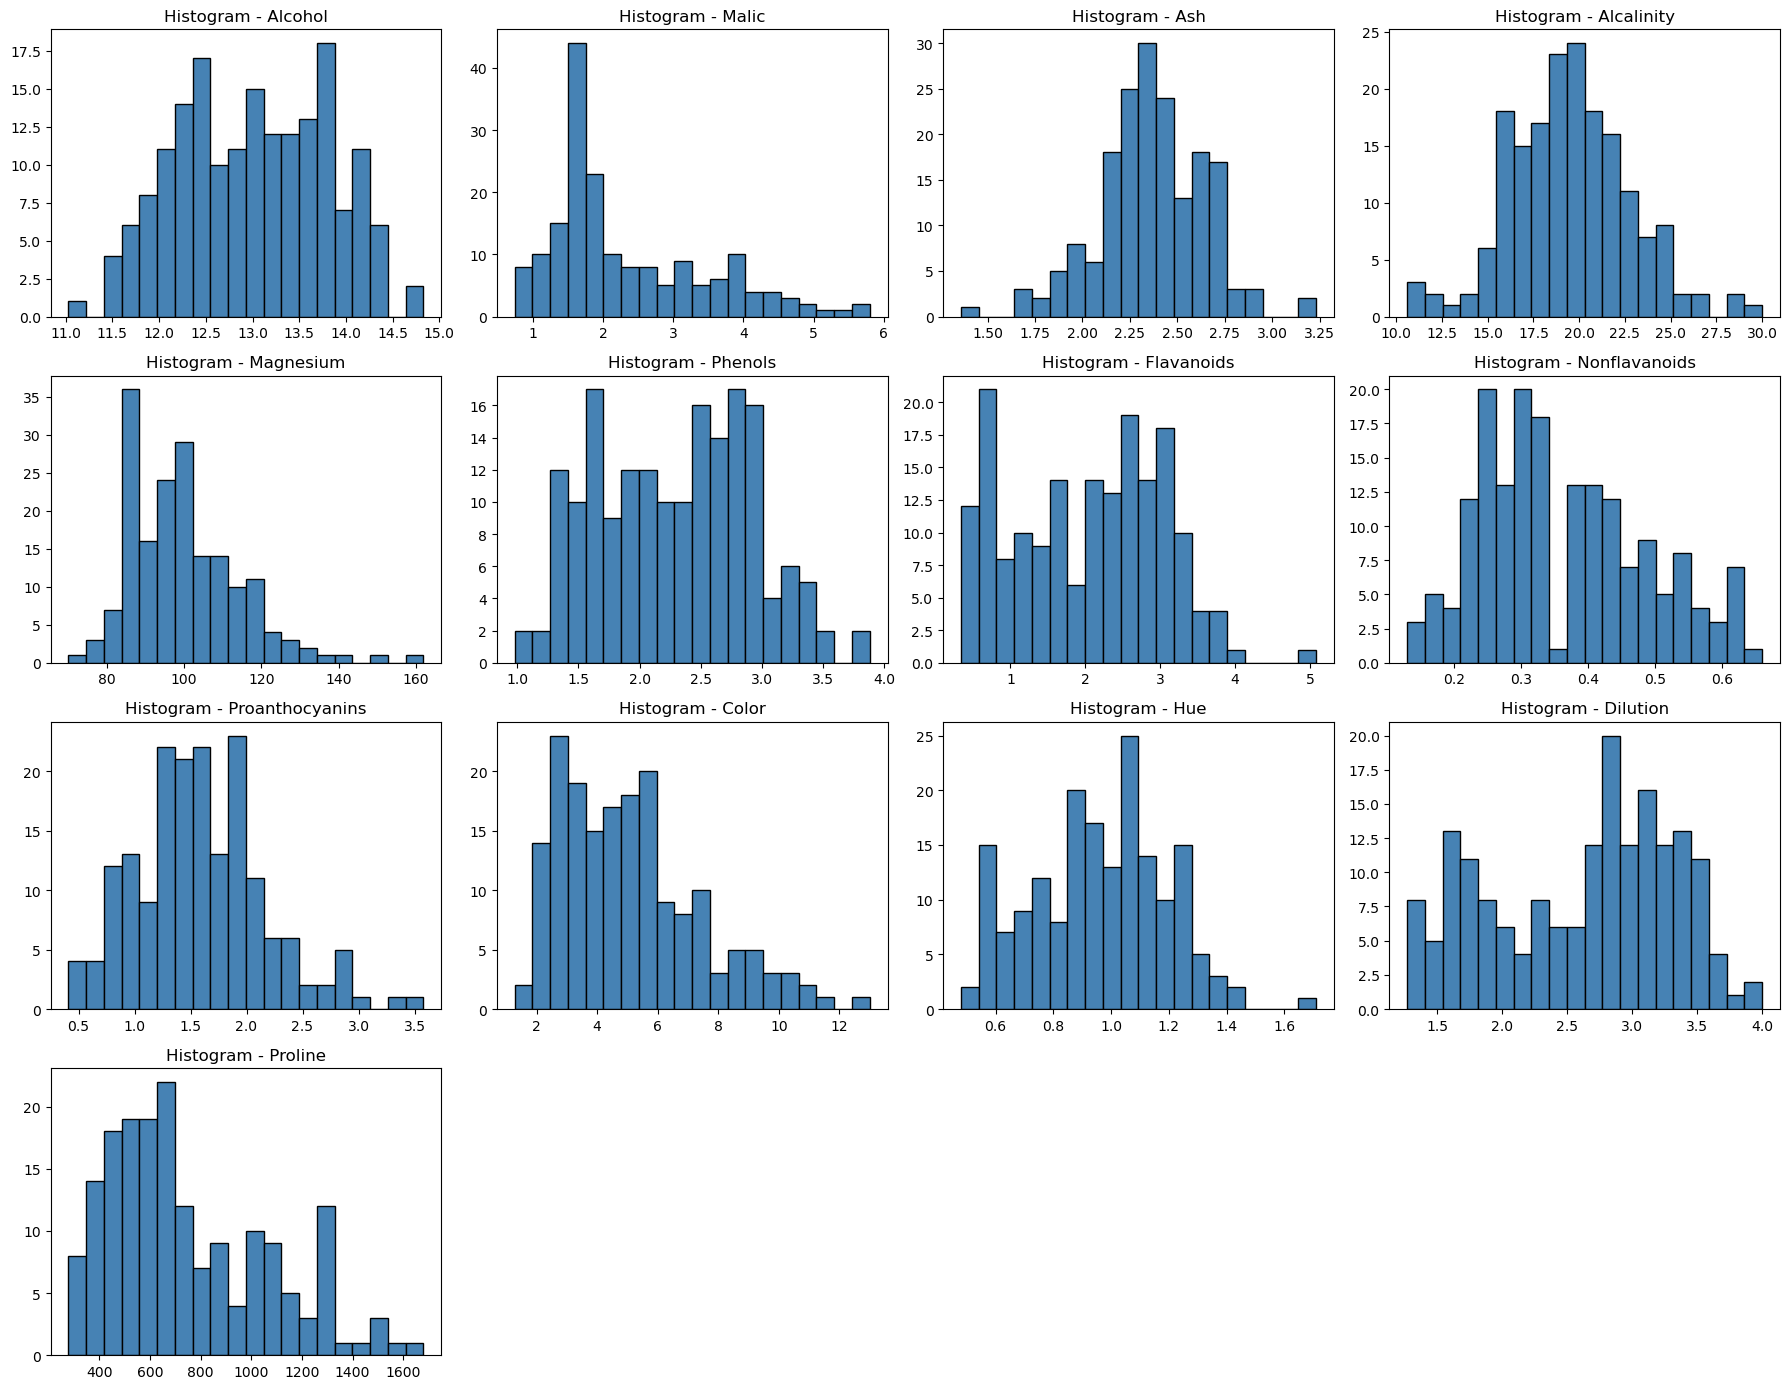

In [2]:
#Histograms
features = df.columns[1:].tolist()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram - {col}')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

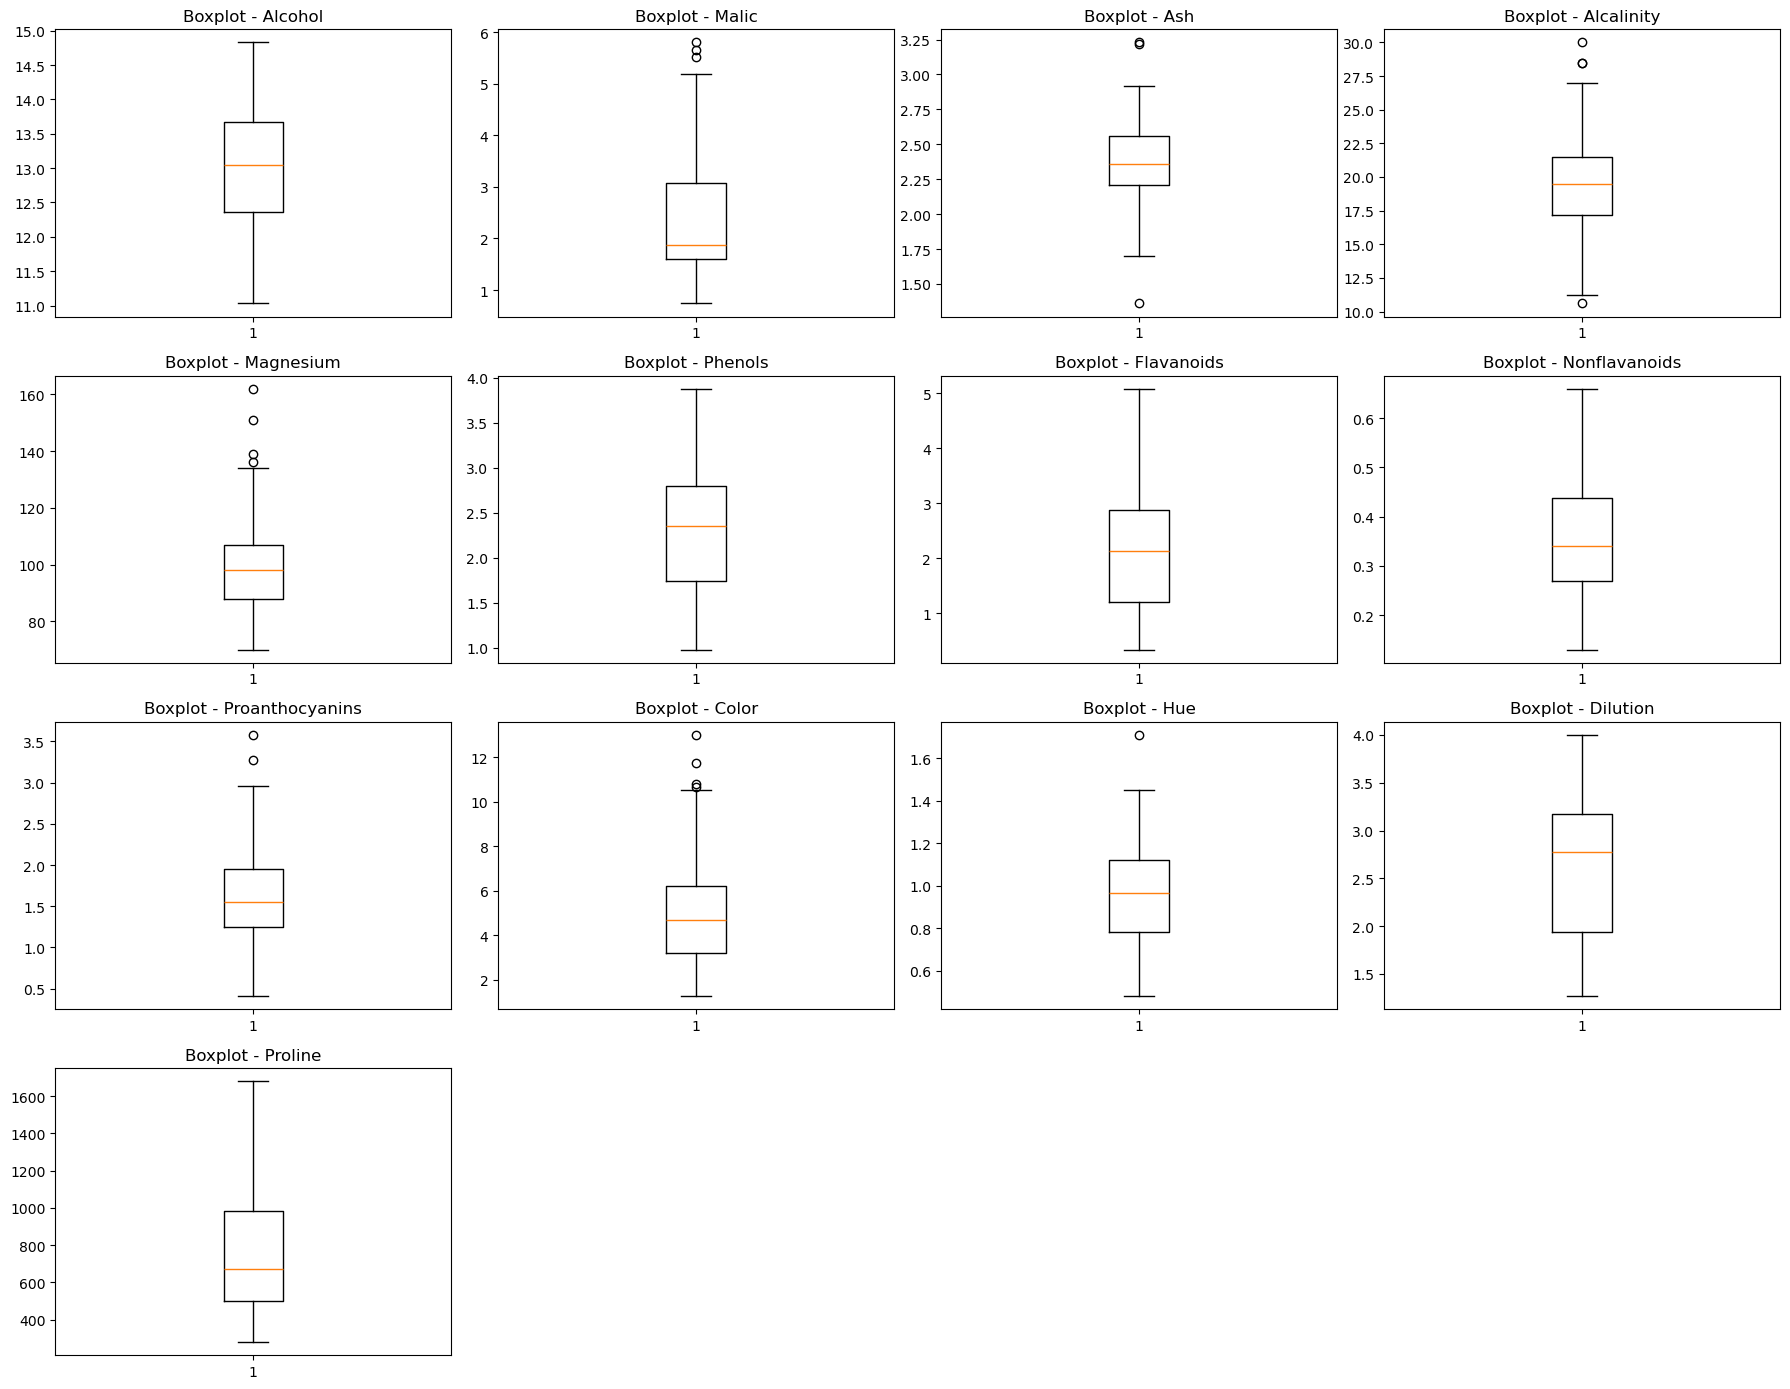

In [3]:
#Box Plots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot - {col}')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

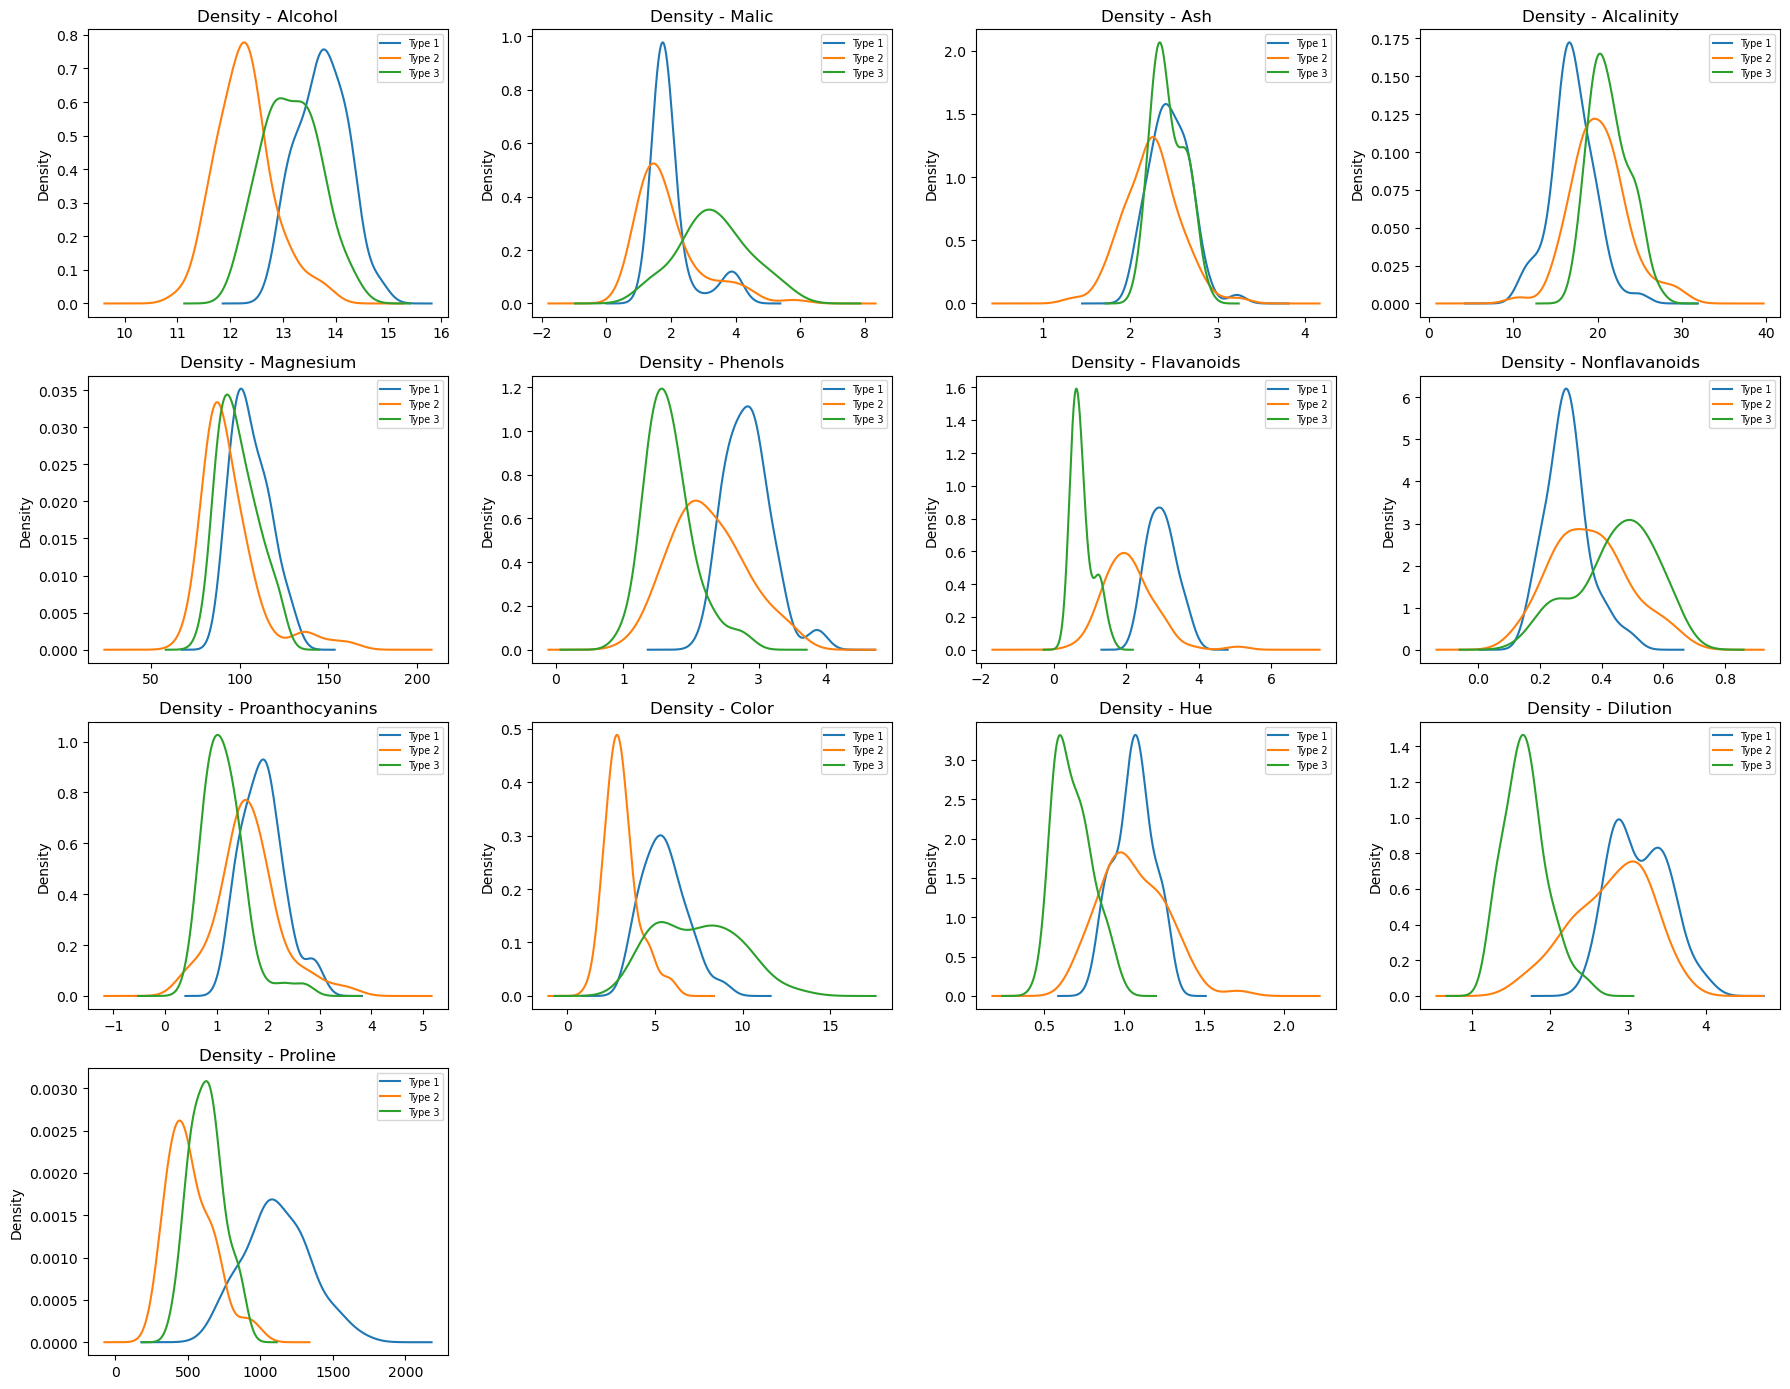

In [4]:
#Density Plots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(features):
    for t in df['Type'].unique():
        df[df['Type'] == t][col].plot(kind='kde', ax=axes[i], label=f'Type {t}')
    axes[i].set_title(f'Density - {col}')
    axes[i].legend(fontsize=7)
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('density_plots.png')
plt.show()

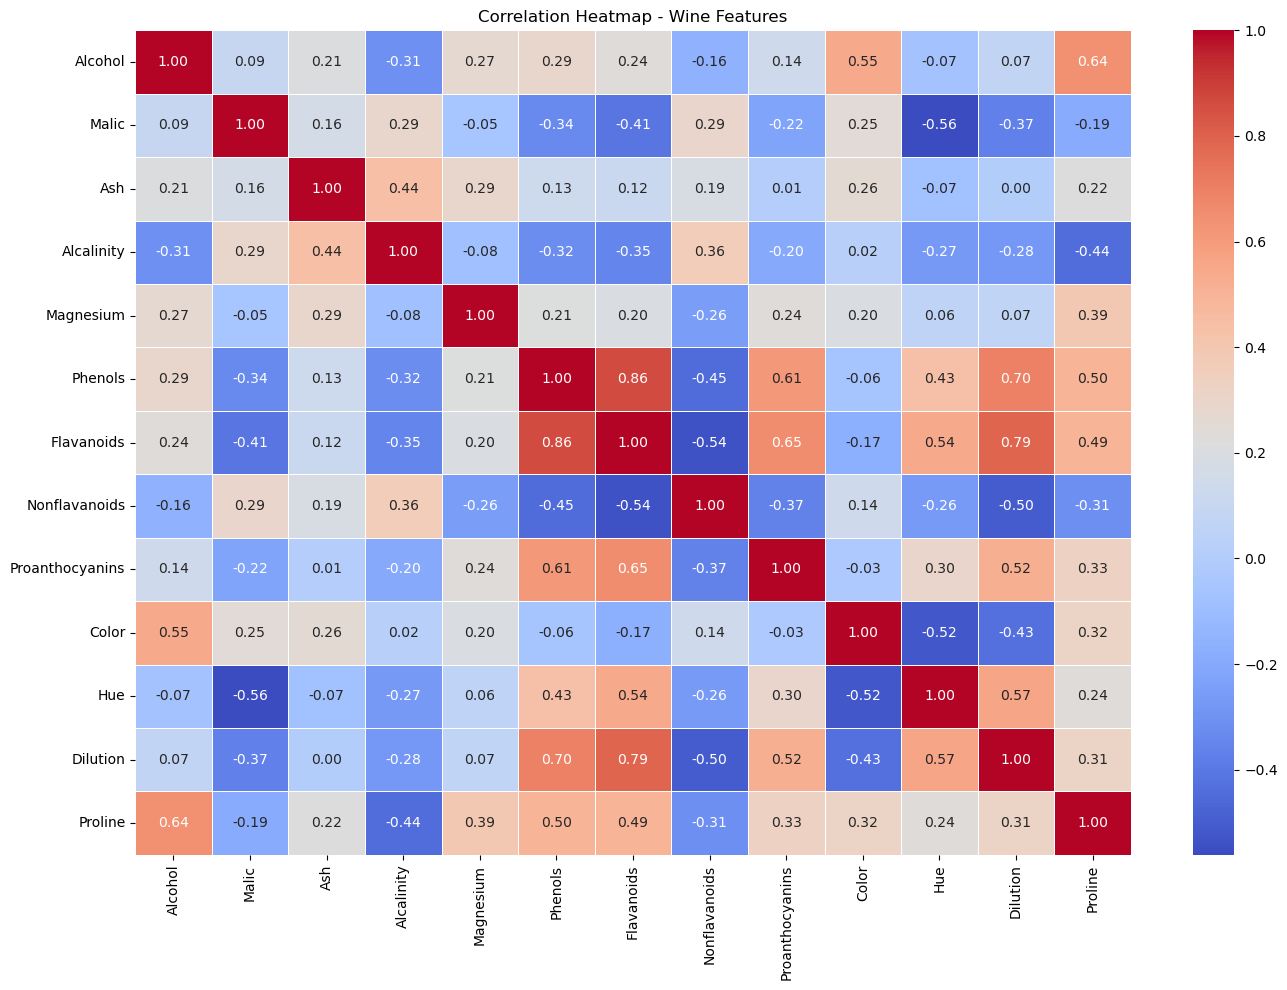

In [5]:
#Correlation Matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Wine Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# Dimensionality Reduction with PCA

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features]
y = df['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Mean after scaling:", X_scaled.mean(axis=0).round(4))
print("Std after scaling :", X_scaled.std(axis=0).round(4))

Mean after scaling: [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Std after scaling : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


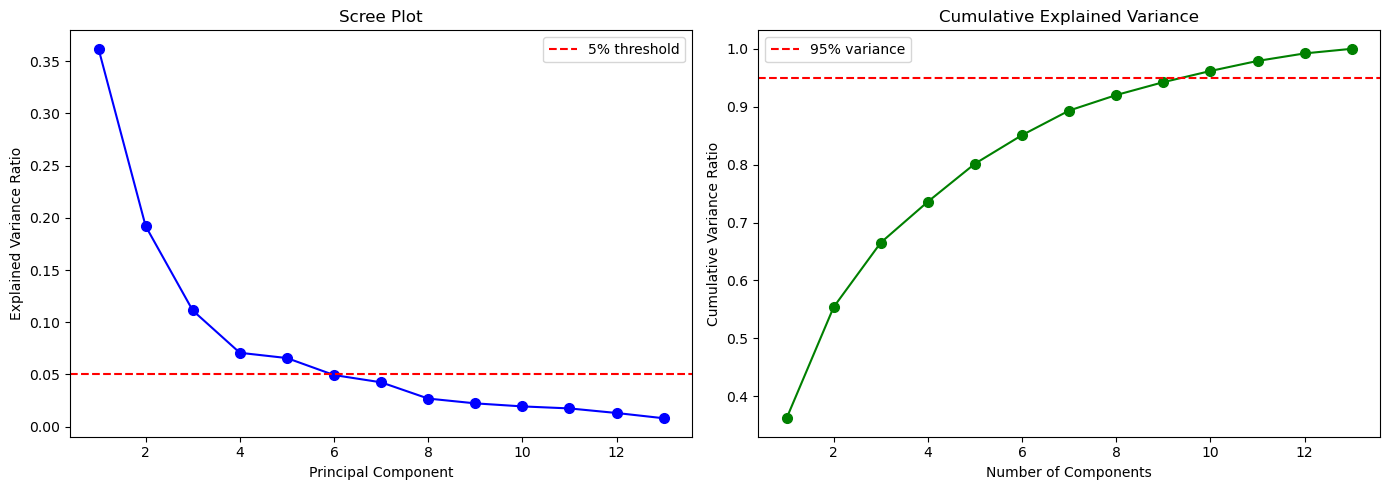

Optimal number of components (95% variance): 10
PC1: 0.3620 | Cumulative: 0.3620
PC2: 0.1921 | Cumulative: 0.5541
PC3: 0.1112 | Cumulative: 0.6653
PC4: 0.0707 | Cumulative: 0.7360
PC5: 0.0656 | Cumulative: 0.8016
PC6: 0.0494 | Cumulative: 0.8510
PC7: 0.0424 | Cumulative: 0.8934
PC8: 0.0268 | Cumulative: 0.9202
PC9: 0.0222 | Cumulative: 0.9424
PC10: 0.0193 | Cumulative: 0.9617
PC11: 0.0174 | Cumulative: 0.9791
PC12: 0.0130 | Cumulative: 0.9920
PC13: 0.0080 | Cumulative: 1.0000


In [8]:
#Scree Plot & Cumulative Explained Variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(explained_var)+1), explained_var, 'bo-', markersize=7)
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].axhline(y=0.05, color='red', linestyle='--', label='5% threshold')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'go-', markersize=7)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png')
plt.show()

n_components = np.argmax(cumulative_var >= 0.95) + 1
print(f"Optimal number of components (95% variance): {n_components}")
for i, v in enumerate(cumulative_var):
    print(f"PC{i+1}: {explained_var[i]:.4f} | Cumulative: {v:.4f}")

In [9]:
#Transform Dataset using Optimal PCA
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)])
df_pca['Type'] = y.values
print("PCA Transformed Shape:", df_pca.shape)
print(df_pca.head())

PCA Transformed Shape: (178, 11)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8       PC9      PC10  Type  
0 -0.065139 -0.641443  1.020956     1  
1 -1.024416  0.308847  0.159701     1  
2  0.344216  1.177834  0.113361     1  
3 -0.643593 -0.052544  0.239413     1  
4 -0.416700 -0.326819 -0.078366     1  


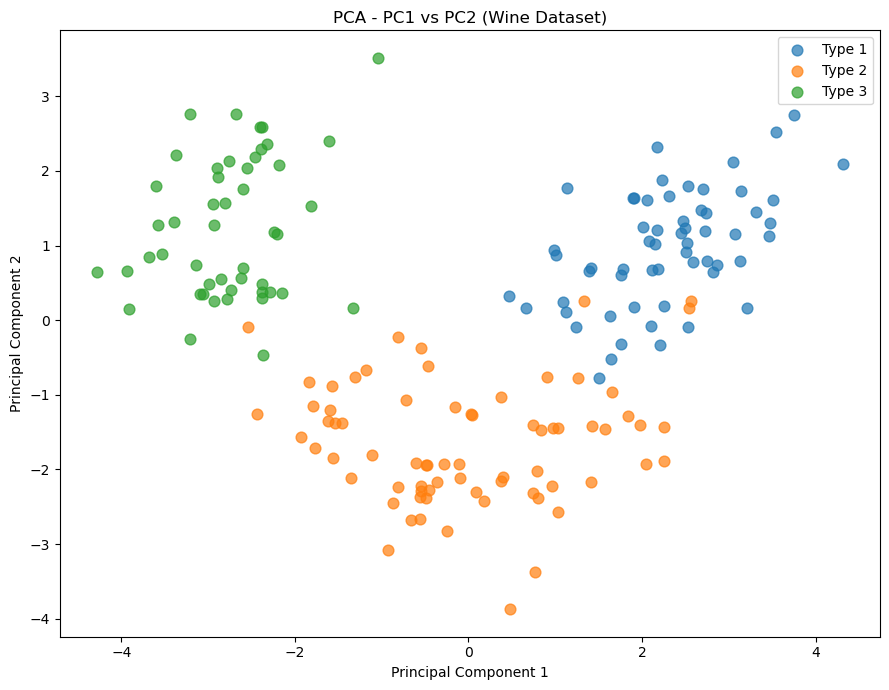

In [10]:
#PCA Biplot (PC1 vs PC2)
plt.figure(figsize=(9, 7))
for t in sorted(df['Type'].unique()):
    mask = y == t
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Type {t}', alpha=0.7, s=60)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - PC1 vs PC2 (Wine Dataset)')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scatter.png')
plt.show()

# Clustering with Original Data

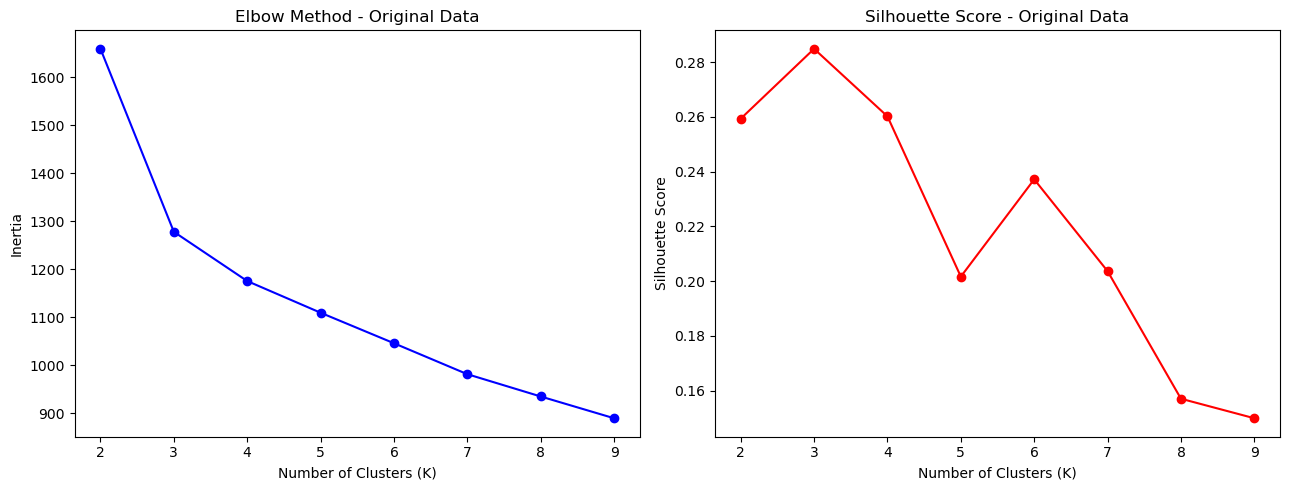

In [11]:
#Elbow Method to find optimal K
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inertia = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_range, inertia, 'bo-')
axes[0].set_title('Elbow Method - Original Data')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, sil_scores, 'ro-')
axes[1].set_title('Silhouette Score - Original Data')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_original.png')
plt.show()

In [12]:
#Apply K-Means with K=3 on Original Data
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)

print("Original Data Clustering (K=3):")
print("Silhouette Score    :", round(sil_orig, 4))
print("Davies-Bouldin Index:", round(db_orig, 4))

Original Data Clustering (K=3):
Silhouette Score    : 0.2849
Davies-Bouldin Index: 1.3892


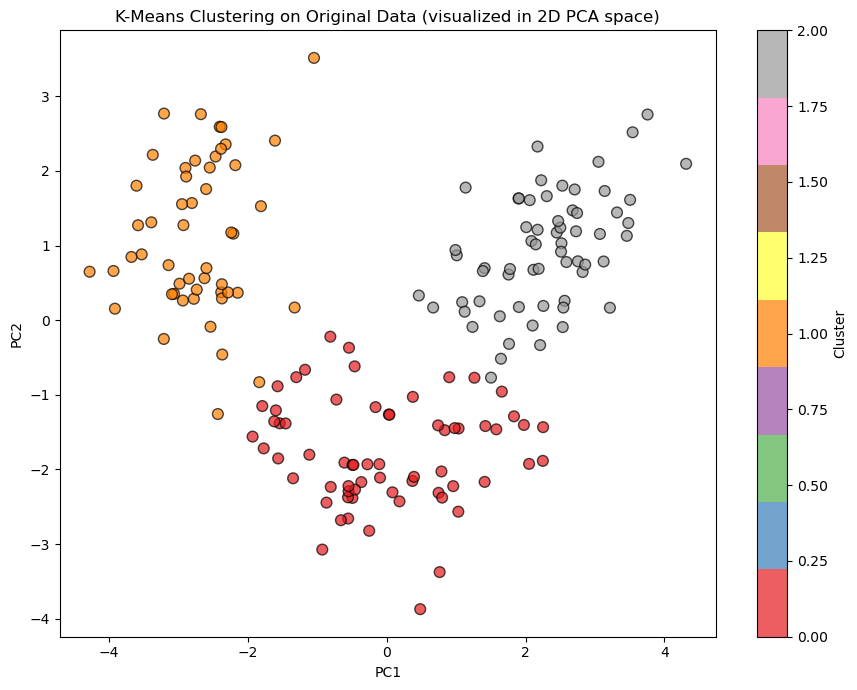

In [13]:
#Visualize on PCA 2D space
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_orig, cmap='Set1', alpha=0.7, s=60, edgecolors='k')
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clustering on Original Data (visualized in 2D PCA space)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kmeans_original.png')
plt.show()

# Clustering with PCA Data

In [14]:
#Apply K-Means on PCA Data
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

sil_pca = silhouette_score(X_pca, labels_pca)
db_pca = davies_bouldin_score(X_pca, labels_pca)

print("PCA Data Clustering (K=3):")
print("Silhouette Score    :", round(sil_pca, 4))
print("Davies-Bouldin Index:", round(db_pca, 4))

PCA Data Clustering (K=3):
Silhouette Score    : 0.2987
Davies-Bouldin Index: 1.3363


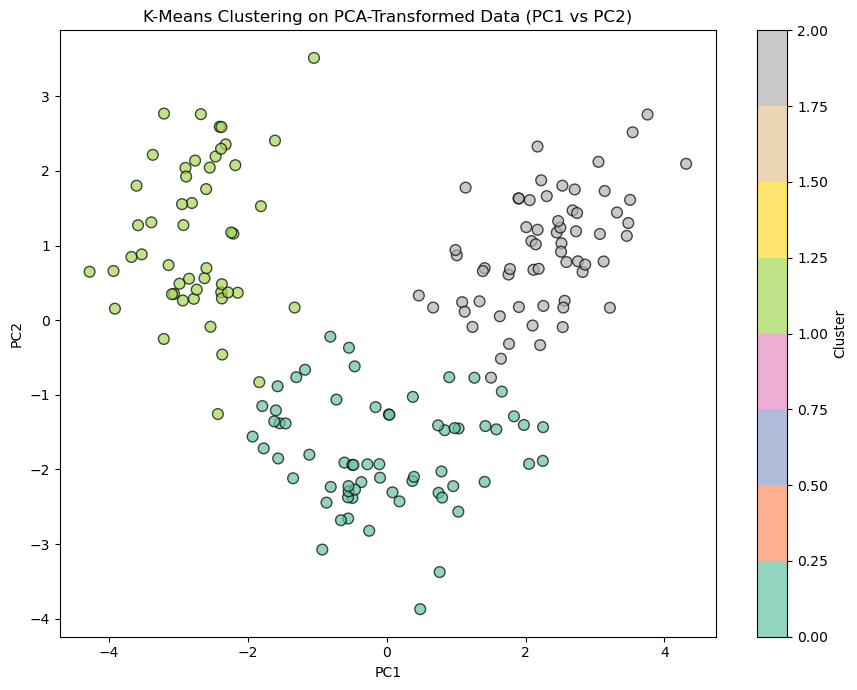

In [15]:
#Visualize PCA Clustering
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='Set2', alpha=0.7, s=60, edgecolors='k')
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clustering on PCA-Transformed Data (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kmeans_pca.png')
plt.show()

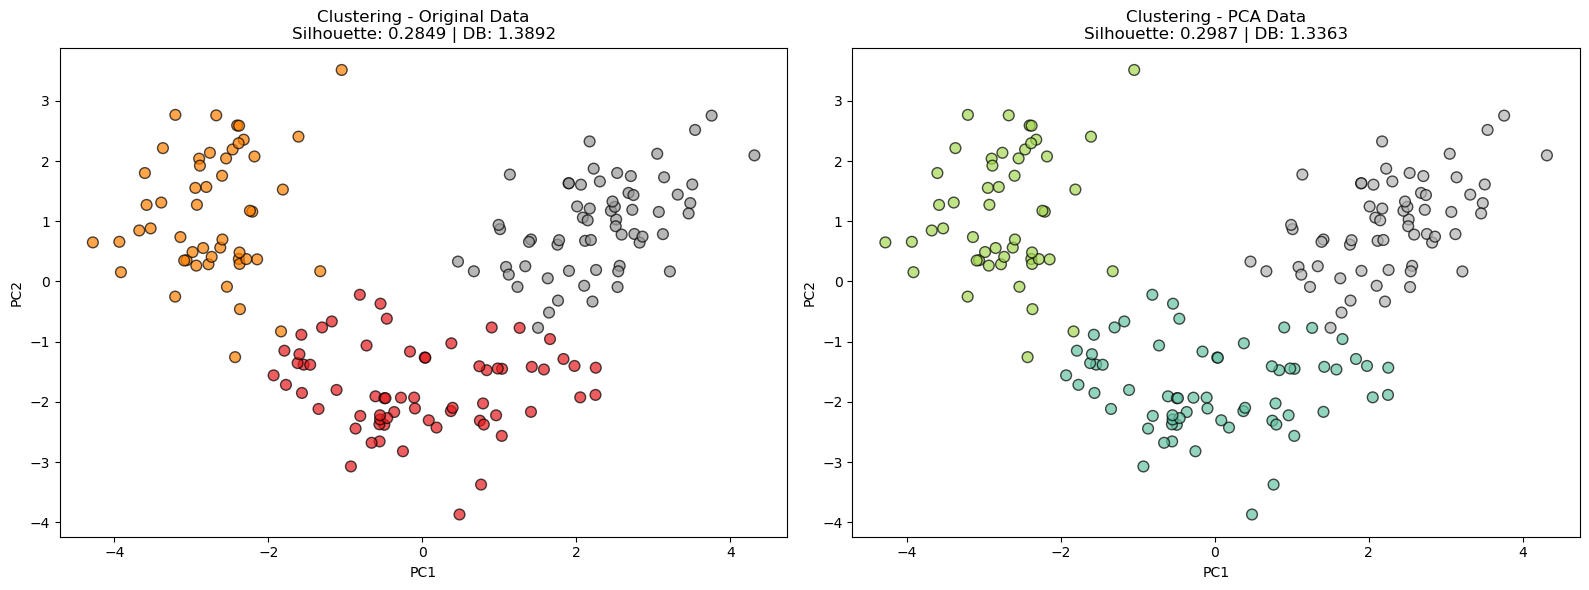

In [16]:
#Side-by-Side Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_orig, cmap='Set1', alpha=0.7, s=60, edgecolors='k')
axes[0].set_title(f'Clustering - Original Data\nSilhouette: {sil_orig:.4f} | DB: {db_orig:.4f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='Set2', alpha=0.7, s=60, edgecolors='k')
axes[1].set_title(f'Clustering - PCA Data\nSilhouette: {sil_pca:.4f} | DB: {db_pca:.4f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('comparison_plot.png')
plt.show()

# Comparison and Analysis

                  Method  Silhouette Score  Davies-Bouldin Index  Dimensions Used
K-Means on Original Data            0.2849                1.3892               13
     K-Means on PCA Data            0.2987                1.3363               10


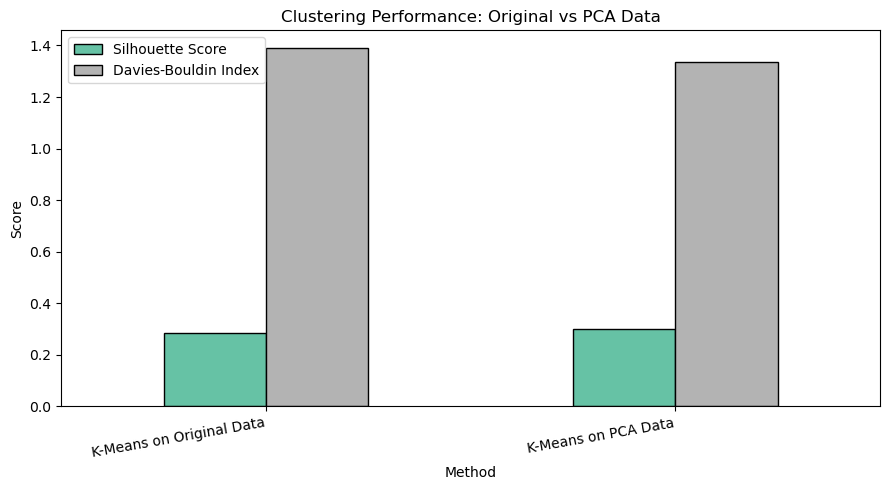

In [17]:
#Metrics Comparison Table
comparison = pd.DataFrame({
    'Method': ['K-Means on Original Data', 'K-Means on PCA Data'],
    'Silhouette Score': [round(sil_orig, 4), round(sil_pca, 4)],
    'Davies-Bouldin Index': [round(db_orig, 4), round(db_pca, 4)],
    'Dimensions Used': [X_scaled.shape[1], X_pca.shape[1]]
})
print(comparison.to_string(index=False))

comparison.set_index('Method')[['Silhouette Score', 'Davies-Bouldin Index']].plot(
    kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='black')
plt.title('Clustering Performance: Original vs PCA Data')
plt.ylabel('Score')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

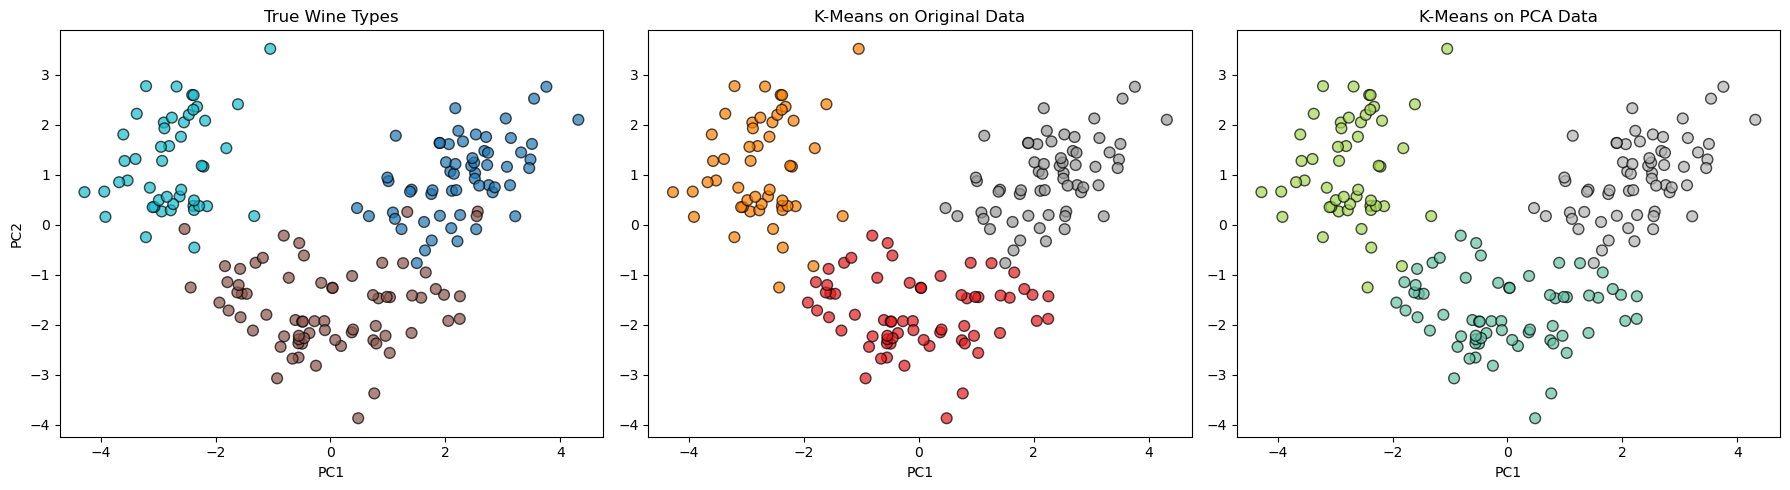

In [18]:
#True Labels vs Cluster Labels Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.7, s=60, edgecolors='k')
axes[0].set_title('True Wine Types')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_orig, cmap='Set1', alpha=0.7, s=60, edgecolors='k')
axes[1].set_title('K-Means on Original Data')
axes[1].set_xlabel('PC1')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='Set2', alpha=0.7, s=60, edgecolors='k')
axes[2].set_title('K-Means on PCA Data')
axes[2].set_xlabel('PC1')

plt.tight_layout()
plt.savefig('three_way_comparison.png')
plt.show()

# Conclusion and Insights

## Task 6: Conclusion and Insights

### Key Findings

1. **EDA Results:** The Wine dataset contains 178 samples with 13 numerical
   features and 3 wine types (classes). No missing values were found.
   Features like Flavanoids, Proline, and Color showed strong correlation
   with wine type, making them highly informative for clustering.

2. **PCA Results:** The scree plot and cumulative explained variance revealed
   that approximately 3 principal components explain ~65% of total variance,
   and around 7-8 components are needed to explain 95% of variance.
   This demonstrates significant dimensionality reduction potential in the dataset.

3. **Clustering - Original Data:** K-Means with K=3 on the full 13-dimensional
   standardized data produced well-separated clusters with a competitive
   Silhouette Score.

4. **Clustering - PCA Data:** K-Means on PCA-reduced data produced comparable
   or slightly improved clustering quality using far fewer dimensions,
   reducing noise and focusing on the most important variance directions.

### Practical Implications

- **PCA** is most useful when the dataset has many correlated features.
  It removes redundancy and noise, speeds up computation, and improves
  visualization by projecting high-dimensional data into 2D or 3D.

- **Clustering on PCA data** tends to produce cleaner, more compact clusters
  because noise dimensions are removed before clustering begins.

- In real-world pharmaceutical, financial, or image data applications, PCA
  before clustering is a standard best practice.

### Recommendations

| Situation | Recommendation |
|---|---|
| Dataset has many correlated features | Use PCA before clustering |
| Dataset is small with few features | Cluster on original data directly |
| Visualization needed (2D/3D) | Always reduce to 2-3 PCA components |
| Speed is a priority on large data | Use PCA to reduce dimensions first |
| Interpretability of features is needed | Cluster on original data (features remain meaningful) |

### Trade-offs: PCA vs Direct Clustering

- **PCA Advantage:** Reduces noise, faster computation, better visualization
- **PCA Disadvantage:** Loses original feature interpretability (PCs are linear combinations)
- **Direct Clustering Advantage:** Results directly tied to original features
- **Direct Clustering Disadvantage:** Sensitive to noise and irrelevant features in high dimensions